<a href="https://colab.research.google.com/github/kavyaanjali-nri/Age-Height-Weight-Speed/blob/main/Copy_of_EDA_Student_Performance_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
rkiattisak_student_performance_in_mathematics_path = kagglehub.dataset_download('rkiattisak/student-performance-in-mathematics')

print('Data source import complete.')


100%|██████████| 8.66k/8.66k [00:00<00:00, 6.60MB/s]

Extracting files...
Data source import complete.


# EDA-Student Performance prediction

#### Predicting student performance through exploratory data analysis (EDA) involves examining various factors that may influence academic outcomes. Here's a general outline of steps you might take:

# Data Collection:
Gather relevant data on student performance, which may include
1. Academic records: grades, test scores, attendance, etc.
2. Demographic information: age, gender, ethnicity, socioeconomic status, etc.
3. Behavioral data: study habits, extracurricular activities, etc.

# Data Cleaning:
Clean the data to handle missing values, outliers, and inconsistencies. This ensures the data is reliable for analysis.
# Exploratory Data Analysis (EDA):
1. Descriptive statistics: Calculate summary statistics (mean, median, standard deviation, etc.) for each variable to understand their distribution.
2. Data visualization: Create plots (histograms, box plots, scatter plots, etc.) to visualize relationships between variables and identify patterns.
3. Correlation analysis: Compute correlation coefficients between variables to identify potential predictors of student performance.
4. Feature engineering: Create new variables or transform existing ones to better capture the relationship between predictors and student performance.
# Model Development:
1. Select an appropriate predictive modeling technique based on the nature of the data and the research question. Common techniques include linear regression, decision trees, random forests, support vector machines, etc.
2. Split the data into training and testing sets to evaluate model performance.
3. Train the model on the training data and assess its performance using appropriate evaluation metrics (e.g., mean squared error, accuracy, etc.).
4. Tune model hyperparameters if necessary to improve performance.
# Model Evaluation:
1. Evaluate the model's performance on the testing data to assess its predictive accuracy.
2. Compare the model's performance to baseline models or other benchmarks.
3. Interpret the model results to understand which factors are most influential in predicting student performance.
# Model Deployment:
1. Once satisfied with the model's performance, deploy it in real-world applications to predict student performance based on new data.
2. Monitor the model's performance over time and update it as needed to maintain accuracy.
3. Throughout this process, it's important to consider ethical implications, such as ensuring fairness and transparency in model development and deployment. Additionally, involving domain experts (e.g., educators, psychologists) can provide valuable insights into the factors that influence student performance.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

In [4]:
df=pd.read_csv('/content/exams.csv')
df.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group D,some college,standard,completed,59,70,78
1,male,group D,associate's degree,standard,none,96,93,87
2,female,group D,some college,free/reduced,none,57,76,77
3,male,group B,some college,free/reduced,none,70,70,63
4,female,group D,associate's degree,standard,none,83,85,86
5,male,group C,some high school,standard,none,68,57,54
6,female,group E,associate's degree,standard,none,82,83,80
7,female,group B,some high school,standard,none,46,61,58
8,male,group C,some high school,standard,none,80,75,73
9,female,group C,bachelor's degree,standard,completed,57,69,77


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
df.describe()

,math score,reading score,writing score
count,1000.000000,1000.000000,1000.000000
mean,67.810000,70.382000,69.140000
std,15.250196,14.107413,15.025917
min,15.000000,25.000000,15.000000
25%,58.000000,61.000000,59.000000
50%,68.000000,70.500000,70.000000
75%,79.250000,80.000000,80.000000
max,100.000000,100.000000,100.000000


In [7]:
df.isna().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [8]:
df.rename(columns={'race/ethnicity':'Race','gender':'Gender','parental level of education':'ParentsEducation'},inplace=True)
df.head(2)

,Gender,Race,ParentsEducation,lunch,test preparation course,math score,reading score,writing score
0,female,group D,some college,standard,completed,59,70,78
1,male,group D,associate's degree,standard,none,96,93,87


In [9]:
df.Race.value_counts()

,count
Race,
group C,323
group D,257
group B,198
group E,143
group A,79


In [10]:
df.ParentsEducation.value_counts()

,count
ParentsEducation,
some college,224
high school,215
associate's degree,204
some high school,177
bachelor's degree,105
master's degree,75


In [11]:
df['Race']=df['Race'].str.replace('group','')
df['ParentsEducation']=df['ParentsEducation'].str.replace('some','')

In [12]:
df.ParentsEducation.value_counts()

,count
ParentsEducation,
college,224
high school,215
associate's degree,204
high school,177
bachelor's degree,105
master's degree,75


In [13]:
df['ParentsEducation']=df.ParentsEducation.str.strip()

In [14]:
def countplot(data, hue=None, column=None, order=None, order_hue=None, saturation=1.0, label_dict=None,text=None):
    """
    Parameters:
    - data: DataFrame
        The input DataFrame.
    - hue: str, optional
        Variable in data to map plot aspects to different colors.
    - column: str, optional
        Categorical variable on the x-axis or y-axis.
    - order: list, optional
        Order to plot the categorical levels in the x-axis or y-axis.
    - order_hue: list, optional
        Order to plot the categorical levels in the hue variable.
    - ascending: bool, optional
        Whether to sort the categories in ascending or descending order.
    - saturation: float, optional
        Proportion to desaturate the plot.
    - label_dict: dict, optional
        Dictionary to map values to custom labels.

    """
    plt.figure(figsize=(10, 6))

    if column:
        plt.title(text)
        ax = sns.countplot(x=column, hue=hue, data=data, order=order, hue_order=order_hue, saturation=saturation)
        plt.legend(loc='upper center')

        if order is not None and label_dict is not None:
            plt.xticks(ticks=range(len(order)), labels=[f' {i}: {label_dict[val]}' for i, val in enumerate(order)])

        # Annotate each bar with its count
        for p in ax.patches:
            height = p.get_height()
            ax.text(p.get_x() + p.get_width() / 2., height, f'{height}', ha="center", va="bottom")

    else:
        raise ValueError("Specify either column_x or column_y")

    plt.show()

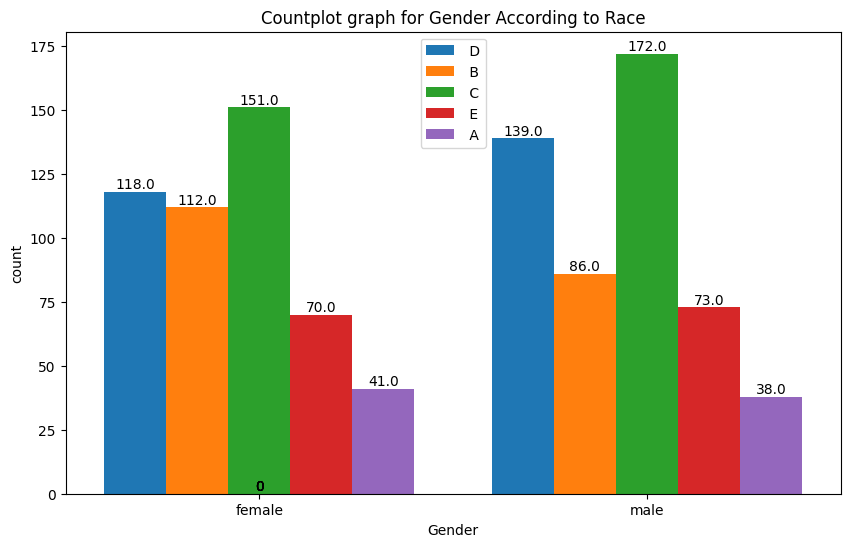

In [15]:
countplot(df,column='Gender',hue='Race',text='Countplot graph for Gender According to Race')

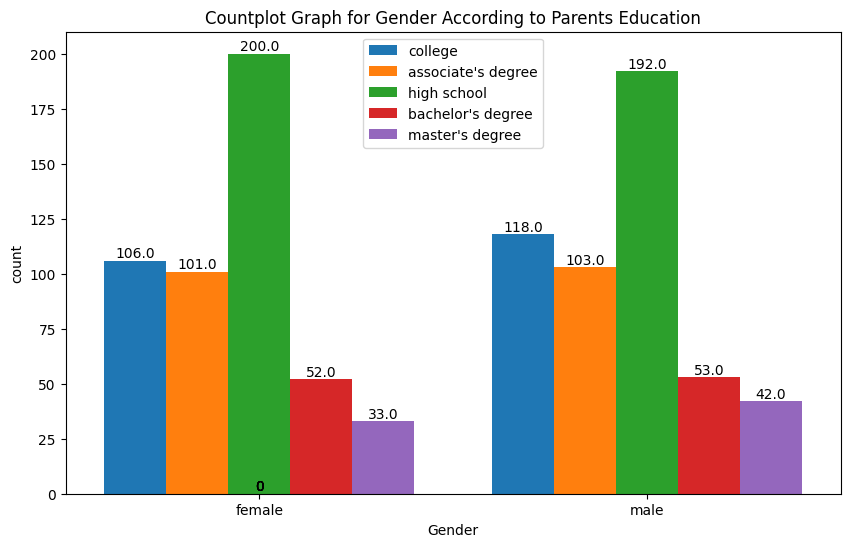

In [16]:
countplot(df,column='Gender',hue='ParentsEducation',text='Countplot Graph for Gender According to Parents Education')

In [17]:
pd.crosstab(df.ParentsEducation,df.Race)

Race,A,B,C,D,E
ParentsEducation,,,,,
associate's degree,21,41,59,59,24
bachelor's degree,4,27,35,25,14
college,15,40,79,55,35
high school,35,76,125,98,58
master's degree,4,14,25,20,12


In [18]:
df.lunch.value_counts()

,count
lunch,
standard,660
free/reduced,340


In [19]:
df.groupby(['Race', 'lunch']).size()

Race  lunch       
A     free/reduced     21
      standard         58
B     free/reduced     75
      standard        123
C     free/reduced    113
      standard        210
D     free/reduced     85
      standard        172
E     free/reduced     46
      standard         97
dtype: int64

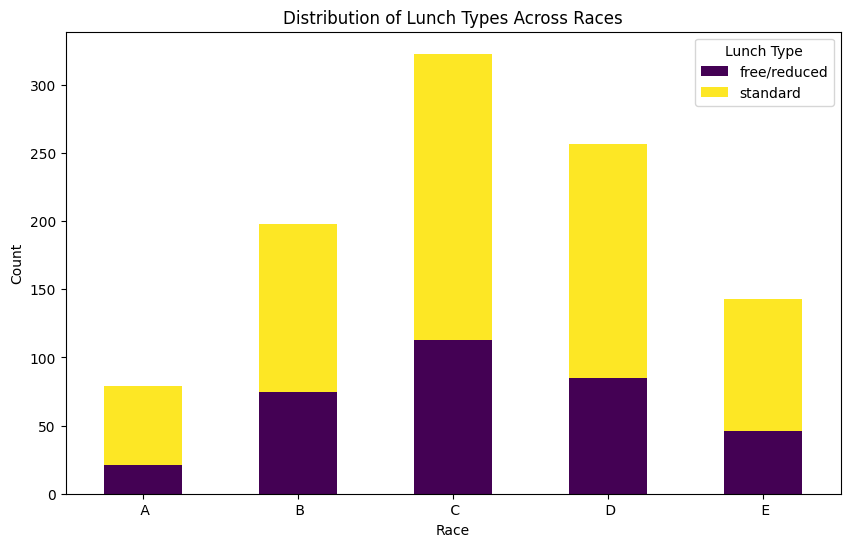

In [20]:
race_lunch_counts = df.groupby(['Race', 'lunch']).size().unstack(fill_value=0)

race_lunch_counts.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Distribution of Lunch Types Across Races')
plt.xlabel('Race')
plt.ylabel('Count')
plt.legend(title='Lunch Type')
plt.xticks(rotation=0)
plt.show()

In [21]:
df[['ParentsEducation','lunch']]

,ParentsEducation,lunch
0,college,standard
1,associate's degree,standard
2,college,free/reduced
3,college,free/reduced
4,associate's degree,standard
...,...,...
995,college,standard
996,college,standard
997,high school,standard
998,high school,standard


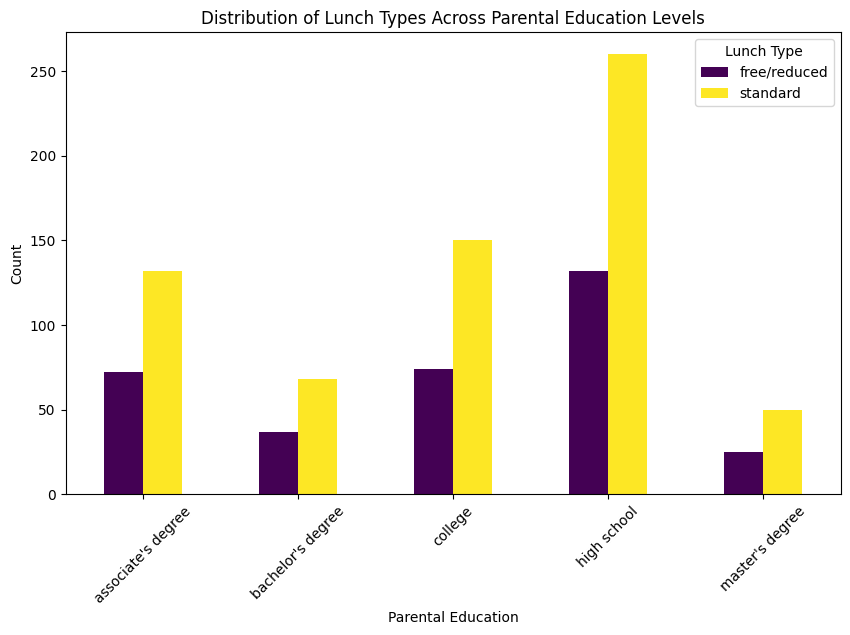

In [22]:
parent_lunch_counts = df.groupby(['ParentsEducation', 'lunch']).size().unstack(fill_value=0)

parent_lunch_counts.plot(kind='bar', figsize=(10, 6), colormap='viridis')

plt.title('Distribution of Lunch Types Across Parental Education Levels')
plt.xlabel('Parental Education')
plt.ylabel('Count')

plt.legend(title='Lunch Type')
plt.xticks(rotation=45)

plt.show()

In [23]:
df[['test preparation course','Gender','Race']]

,test preparation course,Gender,Race
0,completed,female,D
1,none,male,D
2,none,female,D
3,none,male,B
4,none,female,D
...,...,...,...
995,none,male,C
996,none,male,C
997,completed,female,A
998,none,male,E


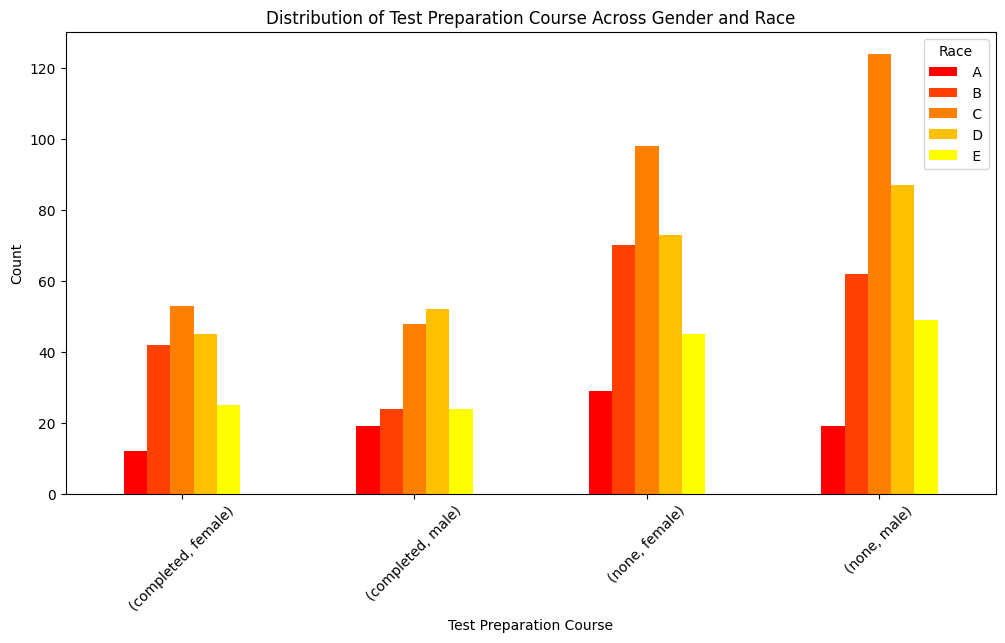

In [24]:
course_counts = df.groupby(['test preparation course', 'Gender', 'Race']).size().unstack(fill_value=0)

# Plot grouped bar plot
course_counts.plot(kind='bar', figsize=(12, 6), colormap='autumn')

# Add title and labels
plt.title('Distribution of Test Preparation Course Across Gender and Race')
plt.xlabel('Test Preparation Course')
plt.ylabel('Count')

# Show legend
plt.legend(title='Race')

# Rotate x-axis labels
plt.xticks(rotation=45)

# Show plot
plt.show()

In [25]:
df.columns

Index(['Gender', 'Race', 'ParentsEducation', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [26]:
## Feature Engineering-> Creating a New column -Total Scores: Addition of All scores (Writing, Math , Reading)
df['Total Score']=df['writing score']+df['reading score']+df['math score']

In [28]:
df[['writing score','reading score','math score','Total Score']].head(10)

,writing score,reading score,math score,Total Score
0,78,70,59,207
1,87,93,96,276
2,77,76,57,210
3,63,70,70,203
4,86,85,83,254
5,54,57,68,179
6,80,83,82,245
7,58,61,46,165
8,73,75,80,228
9,77,69,57,203


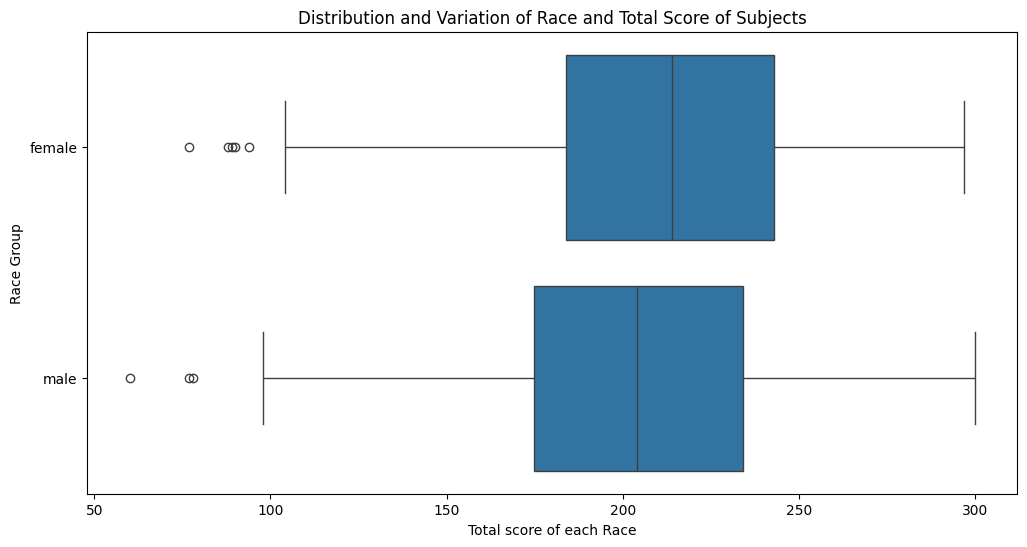

In [27]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df,x='Total Score',y='Gender')
plt.xlabel("Total score of each Race")
plt.ylabel("Race Group")
plt.title("Distribution and Variation of Race and Total Score of Subjects")
plt.show()

In [29]:
df['Total Score'].max()

300

In [30]:
df['Total Score'].min()

60

In [31]:
df['Status'] = pd.cut(df['Total Score'], bins=[0, 100, 200,250, float('inf')], labels=['Insufficient', 'Good', 'Very Good','Excellent'])
df.Status

,Status
0,Very Good
1,Excellent
2,Very Good
3,Very Good
4,Excellent
...,...
995,Very Good
996,Very Good
997,Very Good
998,Very Good


In [32]:
df.Status.value_counts()

,count
Status,
Very Good,417
Good,414
Excellent,160
Insufficient,9


<Figure size 2000x1000 with 0 Axes>

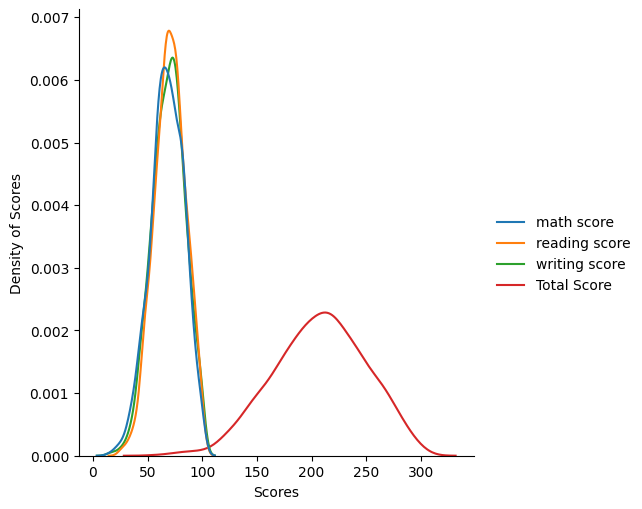

In [33]:
plt.figure(figsize=(20,10))
sns.displot(data=df[['math score', 'reading score', 'writing score','Total Score']], kind="kde")
plt.xlabel('Scores')
plt.ylabel('Density of Scores')
plt.show()